## Anterior/posterior and medial/lateral gene pathways

**Overview**

In this tutorial, we will assess pathways involved in the anterior/posterior and medial/lateral axes of the hippocmapus

**0 - Import libraries**

In [1]:
import os
import sys

import hippomaps as hm
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
import seaborn as sns

from brainspace.mesh.mesh_io import read_surface
from sklearn.metrics import r2_score
from sklearn.cross_decomposition import PLSRegression
from sklearn.discriminant_analysis import StandardScaler

sys.path.append(os.path.abspath(".."))
import hippogenes as hg

/host/yeatman/local_raid/ango/anaconda3/lib/python3.8/site-packages/pandas/core/computation/expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


**1 - Load gene expression data**

In [2]:
expression = hg.load_expression(data_dir="./data")

**2 - Load geodesic anterior-posterior and medial-lateral maps**

In [3]:
hm_path = os.path.dirname(hm.__file__)

surface = read_surface(os.path.join(hm_path, "resources", "canonical_surfs", "tpl-avg_space-unfold_den-0p5mm_label-hipp_midthickness.surf.gii"))

ap_axis = surface.Points[:,0]
ml_axis = surface.Points[:,1]

**3 - Partial least square analyses (PLS)**

In [7]:
def pls(expression, y, n_components=5):
    
    X = StandardScaler().fit_transform(expression)
    Y = StandardScaler().fit_transform(y.reshape(-1, 1))
    
    model = PLSRegression(n_components=n_components)
    model.fit(X, Y)
    
    XL = model.x_loadings_
    YL = model.y_loadings_
    XS = model.x_scores_
    YS = model.y_scores_
    XW = model.x_weights_
    YW = model.y_weights_
    
    r2 = np.zeros(n_components)
    for i in range(n_components):
        Y_pred = np.dot(XS[:, i].reshape(-1, 1), YL[:,i].reshape(1, -1))
        r2[i] = r2_score(Y, Y_pred)
        
        if np.corrcoef(XS[:, i], Y[:, 0])[0, 1] < 0:
            XL[:,i] *= - 1
            XS[:, i] *= -1
            YL[:, i] *= -1
            YS[:, i] *= -1
            
    return XL, YL, XW, YW, r2


def pls_perm(expression, y, n_components=5, n_perm=1000, den="0p5mm"):
    
    _, _, _, _, r2_obs = pls(expression, y, n_components)
    
    null = np.zeros((n_perm, n_components))
    r2_perm = np.zeros((n_perm, n_components))
    
    _, permuted_map, _, _ = hm.stats.eigenstrapping(y, y, nperm=n_perm, label="hipp", den=den)
    
    for i in range(n_perm):
        _, _, _, _, r2_perm[i] = pls(expression, permuted_map[:,i], n_components=n_components)
    
    pval = np.zeros(n_components)
    for i in range(n_components):
        pval[i] = (np.sum(np.abs(r2_perm[:,i]) >= np.abs(r2_obs[i])) + 1) / (n_perm + 1)
        
    return pval, r2_perm


def pls_bootstrap(expression, y, n_components=5, n_bootstrap=1000, seed=0):
    
    rng = np.random.default_rng(seed)
    R, G = expression.shape
    XW_bootstrap = np.zeros((G, n_bootstrap, n_components))

    _, _, XW_obs, _, _ = pls(expression, y, n_components=n_components)
       
    for i in range(n_bootstrap):   
        idx = rng.integers(0, R, size=R)
        
        y_bootstrap = y[idx]
        x_bootstrap = expression.iloc[idx,:]
        _, _, XW_tmp, _, _ = pls(x_bootstrap, y_bootstrap, n_components=n_components)
              
        for k in range(n_components):                      
            corr = np.corrcoef(XW_obs[:,k], XW_tmp[:,k])[0, 1]
            if corr < 0:
                XW_tmp[:,k] *= -1
                XW_tmp[:,k] *= -1
            
        XW_bootstrap[:,i,:] = XW_tmp
            
    XW_ci_lower = np.percentile(XW_bootstrap, 2.5, axis=1)
    XW_ci_upper = np.percentile(XW_bootstrap, 97.5, axis=1)
    
    XW_sig = (XW_ci_lower > 0) | (XW_ci_upper < 0)
    
    return XW_sig, XW_ci_lower, XW_ci_upper 
    

**3.1 - Medial-lateral axis**

In [18]:
ml_pls = pls(expression, ml_axis)
ml_pls_perm = pls_perm(expression, ml_axis, n_perm=1000, den="0p5mm")
ml_pls_bootstrap = pls_bootstrap(expression, ml_axis, n_components=2, n_bootstrap=1000)

NameError: name 'obs' is not defined

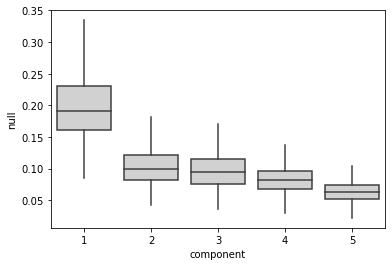

In [19]:
# Components
r2 = ml_pls[4] 
pval, null = ml_pls_perm

n_components = null.shape[1]

df = pd.DataFrame({
    "null": null.ravel(order="F"),
    "component": np.repeat(np.arange(1, n_components + 1), null.shape[0]).astype(str)
})

sns.boxplot(x='component',
            y='null',
            data=df,
            boxprops={"facecolor": "#D1D1D1"}, 
            showcaps=False, 
            showfliers=False
)

for i, (r, p) in enumerate(zip(r2, pval)):
    c = (47/255, 85/255, 151/255) if p <0.05 else (100/255, 100/255, 100/255)
    plt.scatter(x=i, y=obs[i], c=c, zorder=10)
    
plt.ylim((0,1))

In [ ]:
# Wegihted expression
xs = ap_pls["x_scores"][:,0]
z = (xs - np.mean(xs)) / np.std(xs)
#plotting.surfplot_canonical_foldunfold(z, hemis=['L'], labels=['hipp'], tighten_cwindow=True, color_bar='right', color_range="sym", cmap="coolwarm", share=True, den='0p5mm', embed_nb=True, screenshot=True, filename="/host/verges/tank/data/alex/projects/HippoGenes/ap_pls_weighted_expression.png")

In [5]:
# A-P axis 
ap_pls = pls(expression, ap_axis)
ap_pls_perm = pls_perm(expression, ap_axis, n_perm=1000, den="0p5mm")
ap_pls_bootstrap = pls_bootstrap(expression, ap_axis, n_components=2, n_bootstrap=1000)

ValueError: too many values to unpack (expected 3)

In [8]:
ap_pls_bootstrap = pls_bootstrap(expression, ap_axis, n_components=2, n_bootstrap=1000)

(0.0, 1.0)

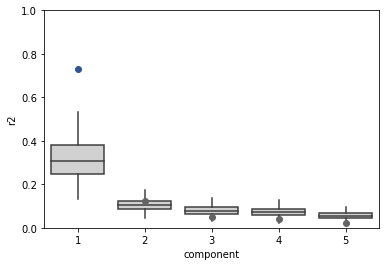

In [16]:
# Components
r2 = ap_pls[4] 
pval, null = ap_pls_perm

n_components = null.shape[1]

df = pd.DataFrame({
    "r2": null.ravel(order="F"),
    "component": np.repeat(np.arange(1, n_components + 1), null.shape[0]).astype(str)
})

sns.boxplot(x='component',
            y='r2',
            data=df,
            boxprops={"facecolor": "#D1D1D1"}, 
            showcaps=False, 
            showfliers=False
)

for i, (r, p) in enumerate(zip(r2, pval)):
    c = "#2f5597" if p <0.05 else "#646464"
    plt.scatter(x=i, y=r2[i], c=c, zorder=10)
    
plt.ylim((0,1))

In [17]:
# Weighted expression (significant)
s = ap_pls[][:,0]
z = (s - np.mean(s)) / np.std(s)
hm.plotting.surfplot_canonical_foldunfold(z, cmap="coolwarm", hemis=["L"], labels=["hipp"], unfoldAPrescale=True, 
                                              share="row", tighten_cwindow=True)

TypeError: tuple indices must be integers or slices, not str